# 

In [18]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries are imported")

Libraries are imported


In [19]:
from pathlib import Path
import pandas as pd

raw_folder = Path("../data/raw")

csv_files = list(raw_folder.glob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file.name)

if not csv_files:
    raise FileNotFoundError("No CSV file found inside data/raw")

data_path = csv_files[0]

df = pd.read_csv(data_path)

print("\nDataset loaded successfully!")
print("File:", data_path.name)
print("Shape:", df.shape)
df.info()
df["Churn"].value_counts(normalize=True) * 100

CSV files found:
WA_Fn-UseC_-Telco-Customer-Churn.csv

Dataset loaded successfully!
File: WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  St

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [20]:
df["Churn"].value_counts(normalize =True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

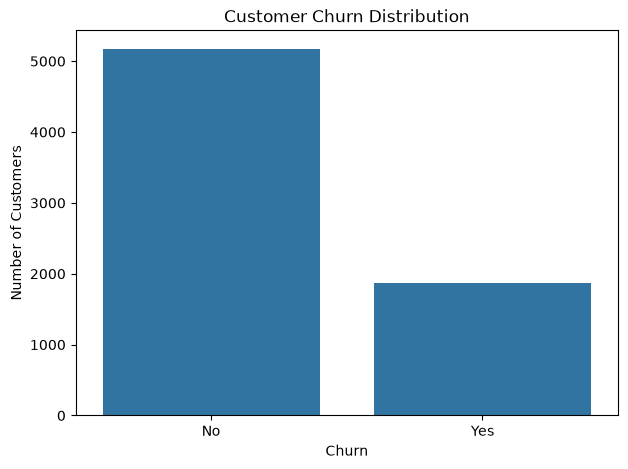

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [22]:
df.isnull().sum()
df["TotalCharges"].dtype
pd.to_numeric(
    df["TotalCharges"],errors = "coerce").isnull().sum()

np.int64(11)

In [23]:
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


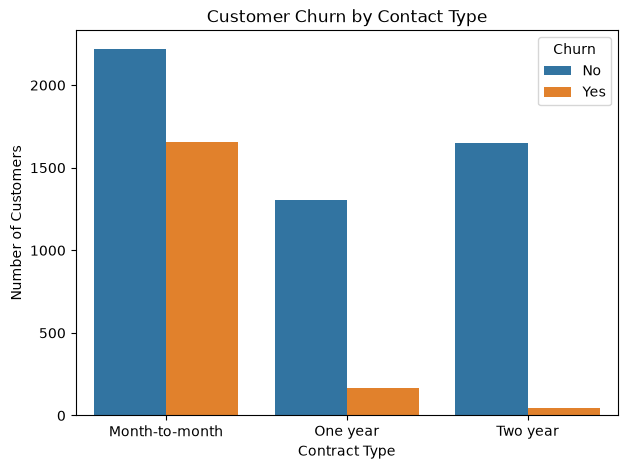

In [25]:
plt.figure(figsize=(7,5))
sns.countplot(
    data= df,
    x = "Contract",
    hue = "Churn"
)
plt.title("Customer Churn by Contact Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

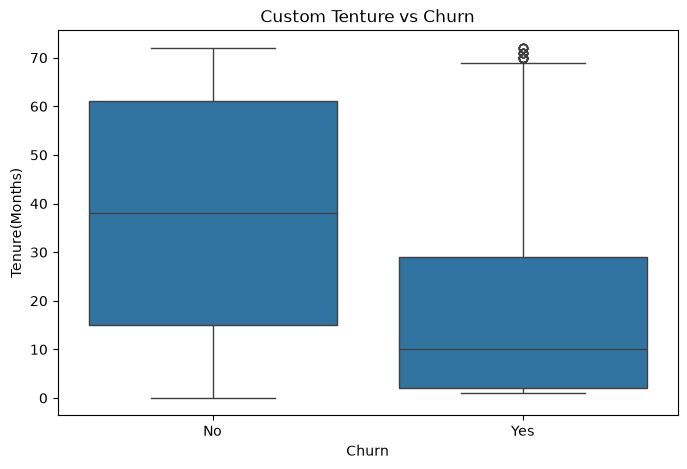

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data = df,
    x="Churn",
    y = "tenure"
)
plt.title("Custom Tenture vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure(Months)")
plt.show()

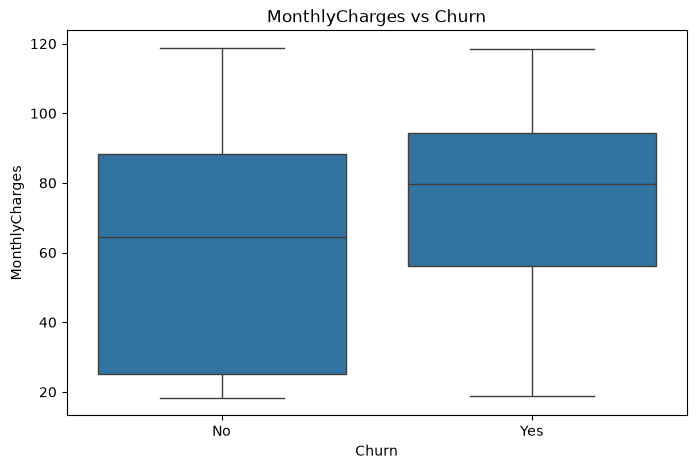

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data = df,
    x="Churn",
    y = "MonthlyCharges"
)
plt.title("MonthlyCharges vs Churn")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

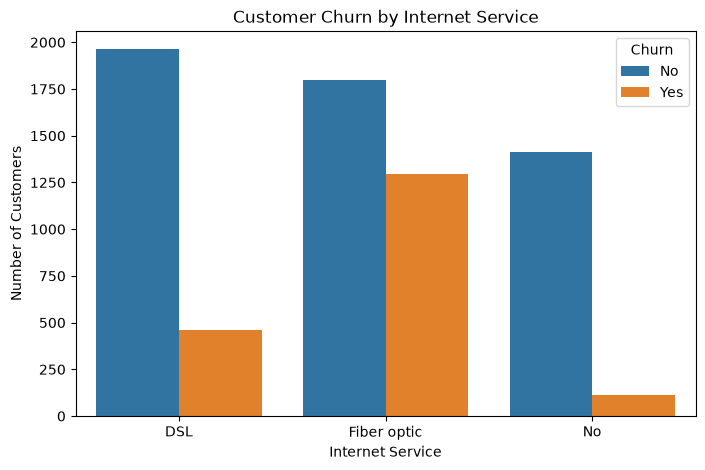

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [29]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [30]:
print("\nTarget:")
print(df["Churn"].value_counts())



Target:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [31]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [32]:
print("\nDuplicates")
print(df.duplicated().sum())


Duplicates
0


In [33]:
print("\nDatatypes:")
print(df.dtypes)


Datatypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [34]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)
print("Total Charges datatypes:",df["TotalCharges"].dtype)
print("Missing TotalCharges:",df["TotalCharges"].isnull().sum())

Total Charges datatypes: float64
Missing TotalCharges: 11


In [35]:
df[df["TotalCharges"].isnull()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [36]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [37]:
print("Missing values after cleaning:")
print(df["TotalCharges"].isnull().sum())

Missing values after cleaning:
0


In [38]:
df =df.drop(columns=["customerID"])
print("New Shape:",df.shape)

New Shape: (7043, 20)


In [39]:
df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [40]:
import pandas as pd
from pathlib import Path

# 1. Load the original dataset again
data_path = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(data_path)

print("Original shape:", df.shape)

# 2. Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# 3. Handle missing TotalCharges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 4. Remove customerID
df = df.drop(columns=["customerID"])

# 5. Convert target variable
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# 6. Verify everything
print("\nFinal shape:", df.shape)

print("\nChurn distribution:")
print(df["Churn"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Original shape: (7043, 21)

Final shape: (7043, 20)

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Missing values:
0

Duplicates:
22

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [41]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5634
Testing samples: 1409


In [43]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [44]:
categorical_features = X.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [47]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (5634, 30)
Testing processed shape: (1409, 30)


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_lr = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Logistic Regression preprocessor created!")

Logistic Regression preprocessor created!


In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [50]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression pipeline created!")

Logistic Regression pipeline created!


In [51]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [52]:
y_pred = logistic_pipeline.predict(X_test)

print("Predictions generated!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated!
First 20 predictions:
[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [53]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("First 10 churn probabilities:")
print(y_prob[:10])

First 10 churn probabilities:
[0.0458386  0.68375823 0.06007238 0.39936455 0.02161438 0.60226845
 0.44714269 0.12890608 0.00289668 0.39605096]


In [54]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8070


In [55]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Churn", "Churn"]
))

              precision    recall  f1-score   support

    No Churn       0.85      0.90      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



Confusion Matrix:
[[927 108]
 [164 210]]


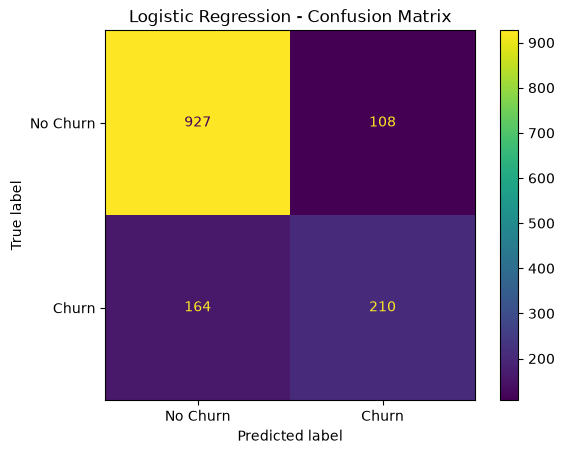

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [57]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8422


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

print(results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8069552874378992, 'Precision': 0.660377358490566, 'Recall': 0.5614973262032086, 'F1 Score': 0.6069364161849711, 'ROC-AUC': 0.8421710713270816}


In [59]:
from sklearn.ensemble import RandomForestClassifier

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [60]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [61]:
rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [62]:
rf_pred = rf_pipeline.predict(X_test)

rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [63]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_roc_auc
}

print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.7721788502484032, 'Precision': 0.5614849187935035, 'Recall': 0.6470588235294118, 'F1 Score': 0.6012422360248447, 'ROC-AUC': 0.8248314345501045}


In [64]:
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.84      1035
       Churn       0.56      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.78      0.77      0.78      1409



Random Forest Confusion Matrix:
[[846 189]
 [132 242]]


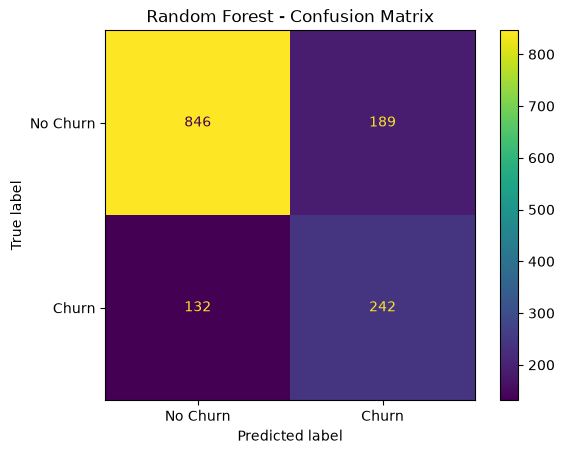

In [65]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

rf_disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["No Churn", "Churn"]
)

rf_disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [66]:
comparison = pd.DataFrame([
    results,
    rf_results
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Random Forest,0.772179,0.561485,0.647059,0.601242,0.824831


In [67]:
print(rf_results)

{'Model': 'Random Forest', 'Accuracy': 0.7721788502484032, 'Precision': 0.5614849187935035, 'Recall': 0.6470588235294118, 'F1 Score': 0.6012422360248447, 'ROC-AUC': 0.8248314345501045}


In [68]:
import xgboost

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [69]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [70]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("XGBoost pipeline created successfully")

XGBoost pipeline created successfully


In [71]:
xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)

xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred),
    "Recall": recall_score(y_test, xgb_pred),
    "F1 Score": f1_score(y_test, xgb_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_prob)
}

xgb_results

{'Model': 'XGBoost',
 'Accuracy': 0.7991483321504613,
 'Precision': 0.6511627906976745,
 'Recall': 0.5240641711229946,
 'F1 Score': 0.5807407407407408,
 'ROC-AUC': 0.8409168410447182}

In [73]:
comparison = pd.DataFrame([
    results,
    rf_results,
    xgb_results
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Random Forest,0.772179,0.561485,0.647059,0.601242,0.824831
2,XGBoost,0.799148,0.651163,0.524064,0.580741,0.840917


In [74]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [75]:
cv = StratifiedKFold(
    n_splits = 5,
    shuffle= True,
    random_state = 42
)

In [76]:
param_grid_lr = {
    "classifier__C":[0.01,0.1,1,10,100]
}

In [77]:
grid_lr = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [78]:
grid_lr.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to

In [80]:
print("Best Parameters:")
print(grid_lr.best_params_)

Best Parameters:
{'classifier__C': 10}


In [81]:
print("Best CV F1 Score:")
print(grid_lr.best_score_)

Best CV F1 Score:
0.5975404089588198


In [82]:
best_lr = grid_lr.best_estimator_
print(best_lr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                      

In [86]:
lr_tuned_pred = best_lr.predict(X_test)
lr_tuned_prob = best_lr.predict_proba(X_test)[:,1]

In [87]:
lr_tuned_results = {
    "Model": "Tuned Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_tuned_pred),
    "Precision": precision_score(y_test, lr_tuned_pred),
    "Recall": recall_score(y_test, lr_tuned_pred),
    "F1 Score": f1_score(y_test, lr_tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, lr_tuned_prob)
}

print(lr_tuned_results)

{'Model': 'Tuned Logistic Regression', 'Accuracy': 0.8048261178140526, 'Precision': 0.6551724137931034, 'Recall': 0.5588235294117647, 'F1 Score': 0.6031746031746031, 'ROC-AUC': 0.841310806272443}


In [122]:
param_grid_rf = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [5, 10, None],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [119]:
grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [120]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know m

In [121]:
print("Best RF Parameters:")
print(grid_rf.best_params_)

print("\nBest RF CV F1 Score:")
print(grid_rf.best_score_)

Best RF Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}

Best RF CV F1 Score:
0.6375199387916102


In [123]:
best_rf = grid_rf.best_estimator_

print(best_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                      

In [124]:
rf_tuned_pred = best_rf.predict(X_test)

rf_tuned_prob = best_rf.predict_proba(X_test)[:, 1]

print("Test samples:", len(X_test))
print("Predictions:", len(rf_tuned_pred))

Test samples: 1409
Predictions: 1409


In [125]:
rf_tuned_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, rf_tuned_pred),
    "Precision": precision_score(y_test, rf_tuned_pred),
    "Recall": recall_score(y_test, rf_tuned_pred),
    "F1 Score": f1_score(y_test, rf_tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, rf_tuned_prob)
}

print(rf_tuned_results)

{'Model': 'Tuned Random Forest', 'Accuracy': 0.7579843860894251, 'Precision': 0.5298372513562387, 'Recall': 0.7834224598930482, 'F1 Score': 0.6321467098166127, 'ROC-AUC': 0.842546952905009}


In [126]:
param_grid_xgb = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [3, 4, 5],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__subsample": [0.8],
    "classifier__colsample_bytree": [0.8]
}

In [127]:
grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [128]:
grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.8], 'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` paramet

In [129]:
print("Best XGBoost Parameters:")
print(grid_xgb.best_params_)

print("\nBest XGBoost CV F1 Score:")
print(grid_xgb.best_score_)

Best XGBoost Parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}

Best XGBoost CV F1 Score:
0.5937142272585626


In [130]:
best_xgb = grid_xgb.best_estimator_

print(best_xgb)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                      

In [131]:
xgb_tuned_pred = best_xgb.predict(X_test)

xgb_tuned_prob = best_xgb.predict_proba(X_test)[:, 1]

print("Test samples:", len(X_test))
print("Predictions:", len(xgb_tuned_pred))

Test samples: 1409
Predictions: 1409


In [132]:
xgb_tuned_results = {
    "Model": "Tuned XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_tuned_pred),
    "Precision": precision_score(y_test, xgb_tuned_pred),
    "Recall": recall_score(y_test, xgb_tuned_pred),
    "F1 Score": f1_score(y_test, xgb_tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, xgb_tuned_prob)
}

print(xgb_tuned_results)

{'Model': 'Tuned XGBoost', 'Accuracy': 0.8041163946061036, 'Precision': 0.6666666666666666, 'Recall': 0.5240641711229946, 'F1 Score': 0.5868263473053892, 'ROC-AUC': 0.8459673460952233}


In [133]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.20, 0.81, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (rf_tuned_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.20,0.389071,0.951872,0.552366
1,0.25,0.415865,0.925134,0.573798
2,0.30,0.439314,0.890374,0.588339
3,0.35,0.459574,0.866310,0.600556
4,0.40,0.489891,0.842246,0.619469
5,0.45,0.510888,0.815508,0.628218
6,0.50,0.529837,0.783422,0.632147
7,0.55,0.553106,0.737968,0.632302
8,0.60,0.571101,0.665775,0.614815
9,0.65,0.608108,0.601604,0.604839


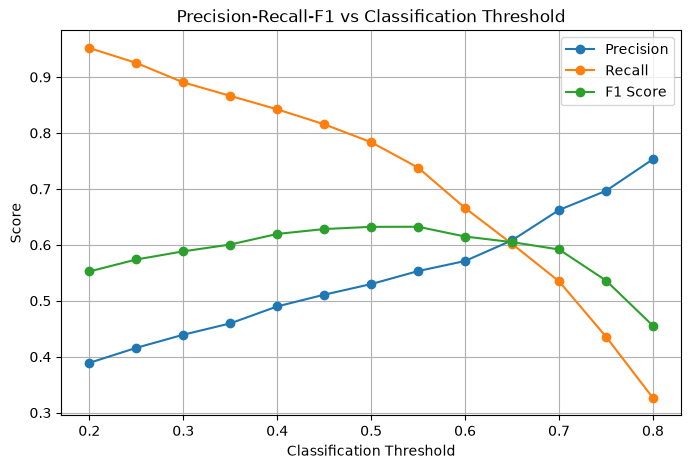

In [134]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 vs Classification Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_tuned_pred)

print(cm)

[[775 260]
 [ 81 293]]


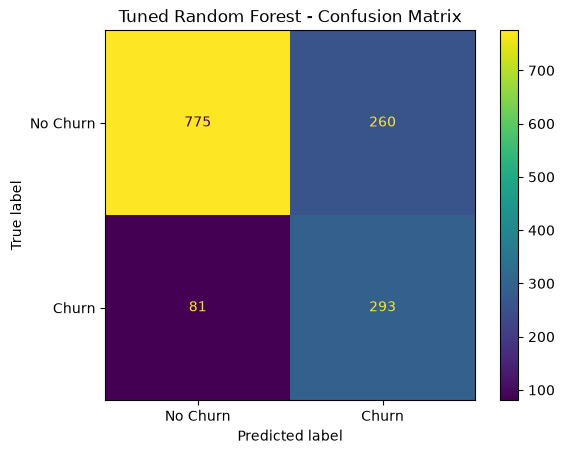

In [136]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Tuned Random Forest - Confusion Matrix")
plt.show()

In [137]:
import shap

# Get the fitted tuned Random Forest pipeline
rf_model = grid_rf.best_estimator_

# Transform the test data
X_test_transformed = rf_model.named_steps["preprocessor"].transform(X_test)

# Get feature names after one-hot encoding
feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of features:", len(feature_names))

Number of features: 30


In [138]:
explainer = shap.TreeExplainer(
    rf_model.named_steps["classifier"]
)

shap_values = explainer.shap_values(X_test_transformed)

print(type(shap_values))

<class 'numpy.ndarray'>


In [139]:
import shap

# Get the best tuned Random Forest pipeline
rf_model = grid_rf.best_estimator_

# Separate preprocessing and classifier
preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Transformed shape: (1409, 30)
Number of feature names: 30


In [140]:
explainer = shap.TreeExplainer(rf_classifier)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values generated successfully!")

SHAP values generated successfully!


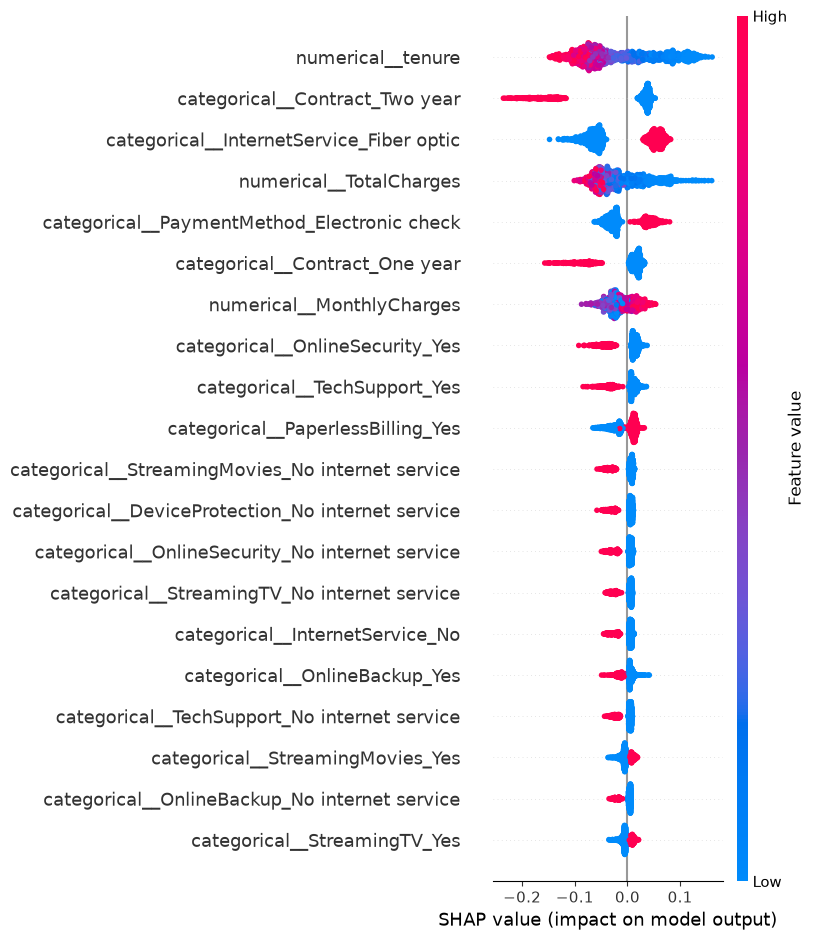

In [141]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names
)

In [142]:
customer_index = 10

customer_data = X_test_transformed[customer_index]
customer_actual = y_test.iloc[customer_index]

print("Actual churn:", customer_actual)

Actual churn: 0


In [143]:
customer_probability = rf_model.predict_proba(
    X_test.iloc[[customer_index]]
)[0, 1]

customer_prediction = int(customer_probability >= 0.5)

print("Predicted churn:", customer_prediction)
print("Churn probability:", customer_probability)

Predicted churn: 0
Churn probability: 0.3566872607108173


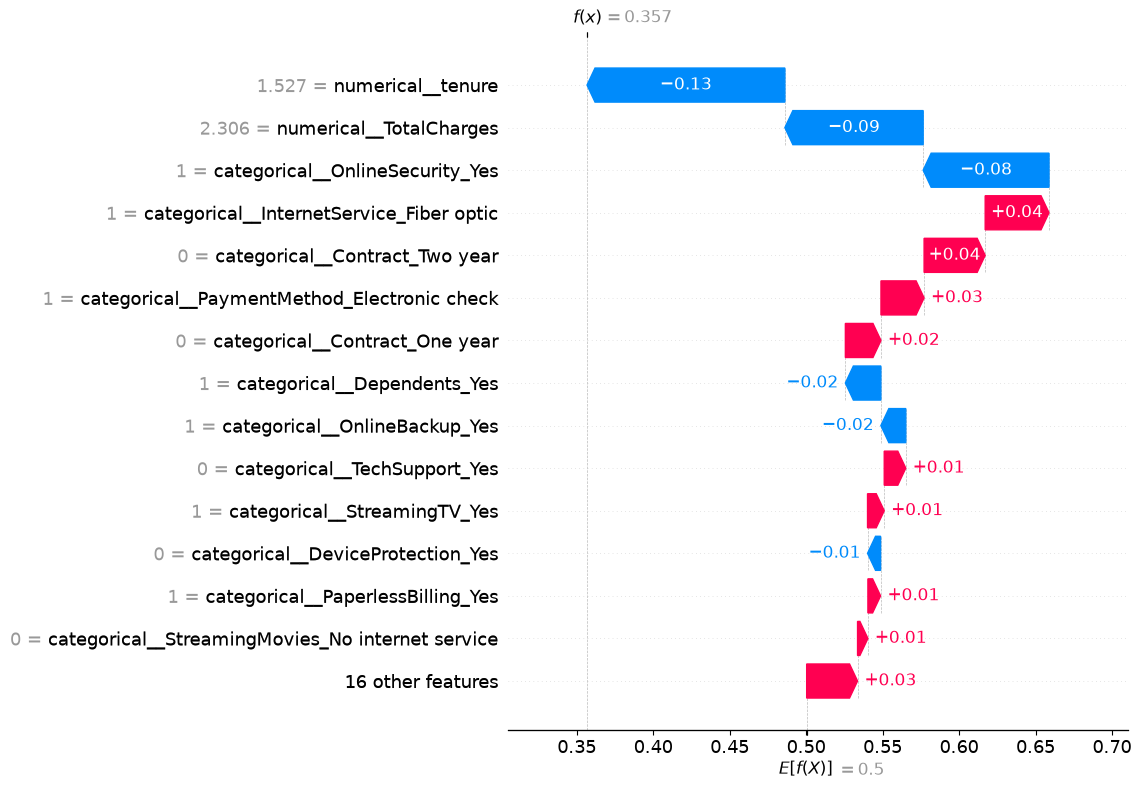

In [144]:
import shap

customer_index = 10

# Transform one customer
customer_transformed = X_test_transformed[customer_index:customer_index + 1]

# Get SHAP values for this customer
customer_shap = shap_values[customer_index, :, 1]

# Create explanation object
customer_explanation = shap.Explanation(
    values=customer_shap,
    base_values=explainer.expected_value[1],
    data=customer_transformed.toarray()[0]
        if hasattr(customer_transformed, "toarray")
        else customer_transformed[0],
    feature_names=feature_names
)

shap.plots.waterfall(customer_explanation, max_display=15)

In [145]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

final_model_path = models_dir / "churn_model.pkl"

joblib.dump(
    grid_rf.best_estimator_,
    final_model_path
)

print("Model saved successfully!")
print("Path:", final_model_path)

Model saved successfully!
Path: ..\models\churn_model.pkl


In [146]:
loaded_model = joblib.load(final_model_path)

test_prediction = loaded_model.predict(X_test.iloc[[0]])
test_probability = loaded_model.predict_proba(X_test.iloc[[0]])[0, 1]

print("Prediction:", test_prediction[0])
print("Churn probability:", test_probability)

Prediction: 0
Churn probability: 0.02833570473777458


In [147]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Best tuned Random Forest
rf_model = grid_rf.best_estimator_

# Separate pipeline components
preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["classifier"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

Transformed shape: (1409, 30)
Number of feature names: 30


In [148]:
explainer = shap.TreeExplainer(rf_classifier)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values generated successfully!")
print(type(shap_values))
print(np.shape(shap_values))

SHAP values generated successfully!
<class 'numpy.ndarray'>
(1409, 30, 2)


In [149]:
shap_values_churn = shap_values[:, :, 1]

In [150]:
if isinstance(shap_values, list):
    shap_values_churn = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_churn = shap_values[:, :, 1]
else:
    shap_values_churn = shap_values

print("Churn SHAP shape:", shap_values_churn.shape)

Churn SHAP shape: (1409, 30)


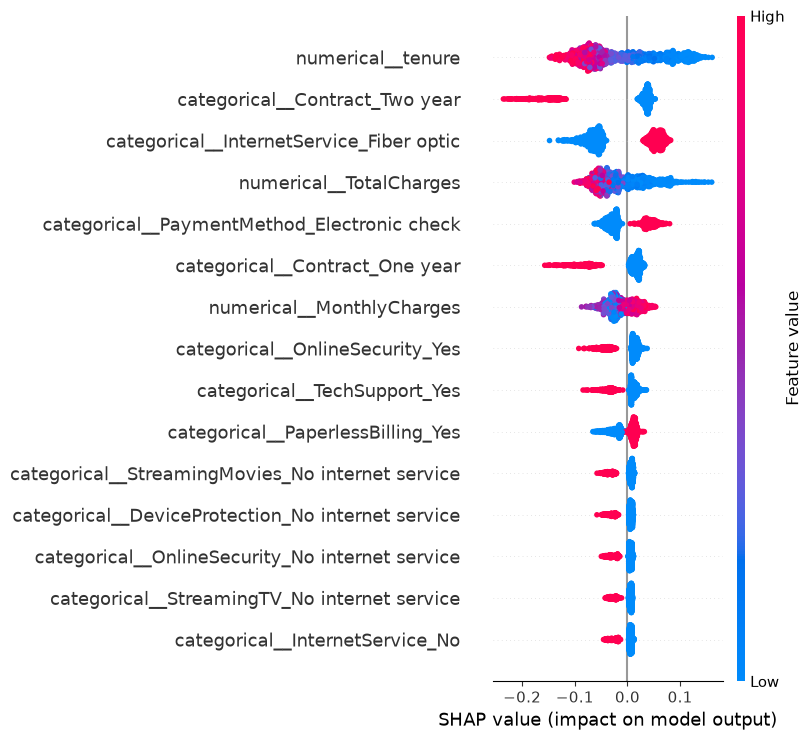

In [151]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

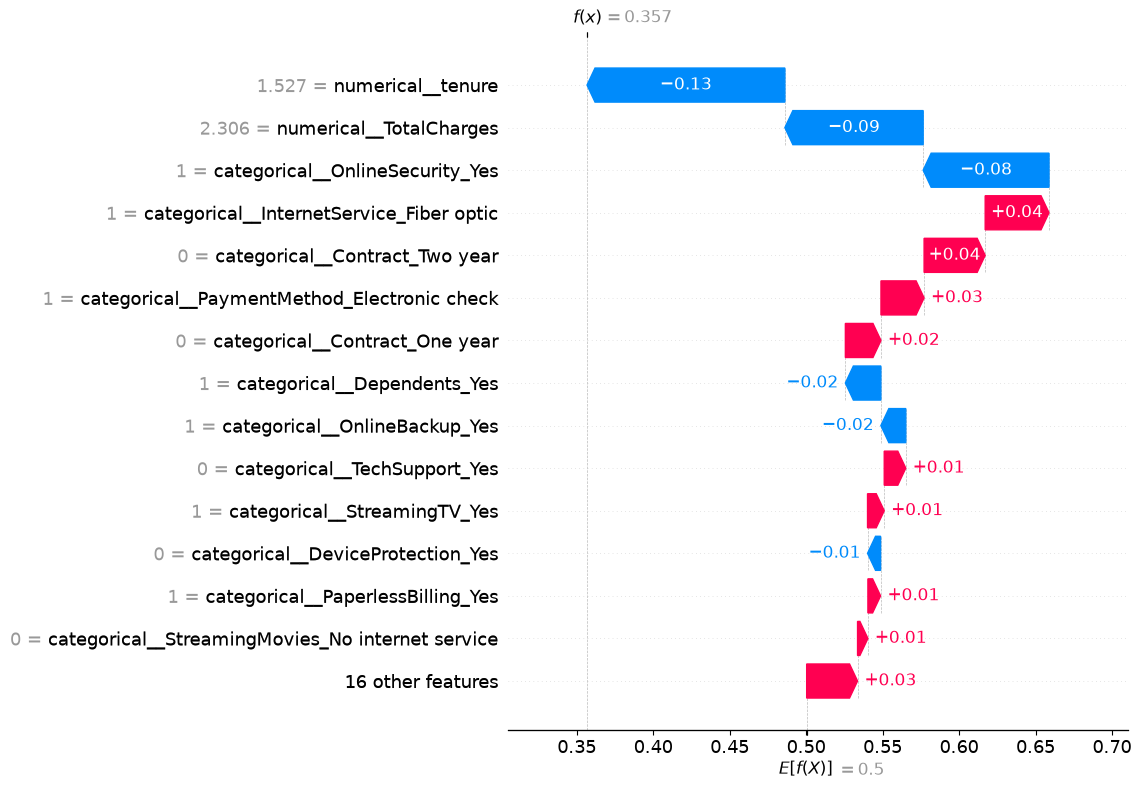

In [152]:
customer_index = 10

customer_transformed = X_test_transformed[
    customer_index:customer_index + 1
]

customer_shap = shap_values_churn[customer_index]

customer_data = (
    customer_transformed.toarray()[0]
    if hasattr(customer_transformed, "toarray")
    else customer_transformed[0]
)

customer_explanation = shap.Explanation(
    values=customer_shap,
    base_values=explainer.expected_value[1],
    data=customer_data,
    feature_names=feature_names
)

shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

In [153]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

final_model_path = models_dir / "churn_model.pkl"

joblib.dump(
    grid_rf.best_estimator_,
    final_model_path
)

print("Model saved successfully!")
print("Path:", final_model_path)

Model saved successfully!
Path: ..\models\churn_model.pkl


In [154]:
loaded_model = joblib.load(final_model_path)

test_customer = X_test.iloc[[0]]

prediction = loaded_model.predict(test_customer)
probability = loaded_model.predict_proba(test_customer)[0, 1]

print("Prediction:", prediction[0])
print("Churn probability:", probability)
print("Churn probability %:", probability * 100)

Prediction: 0
Churn probability: 0.02833570473777458
Churn probability %: 2.833570473777458


In [155]:
print(np.shape(shap_values))

(1409, 30, 2)


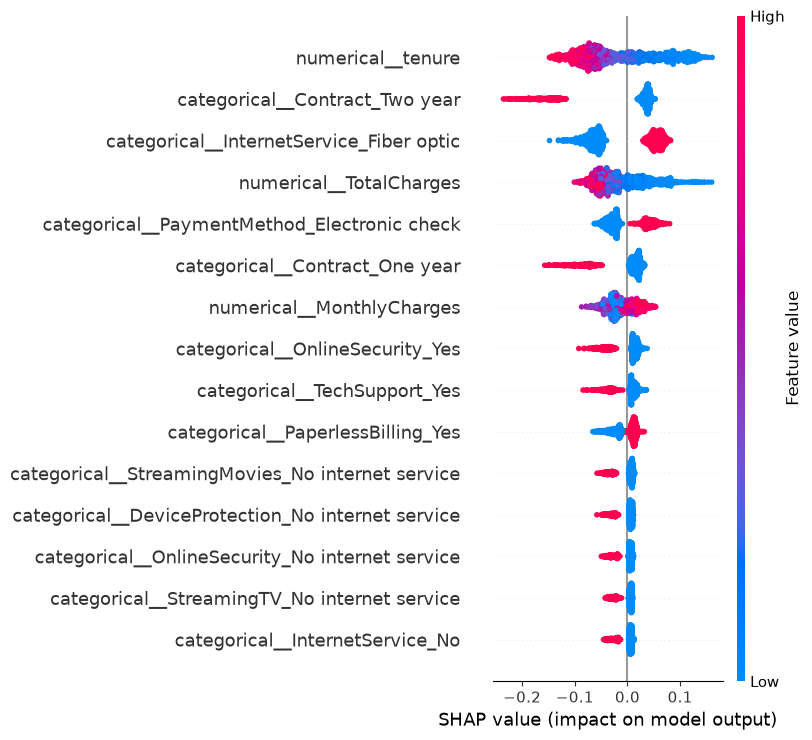

In [156]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

In [157]:
joblib.dump(
    grid_rf.best_estimator_,
    "../models/churn_model.pkl"
)

['../models/churn_model.pkl']

In [158]:
shap_values_churn = shap_values[:, :, 1]

print("Churn SHAP shape:", shap_values_churn.shape)

Churn SHAP shape: (1409, 30)


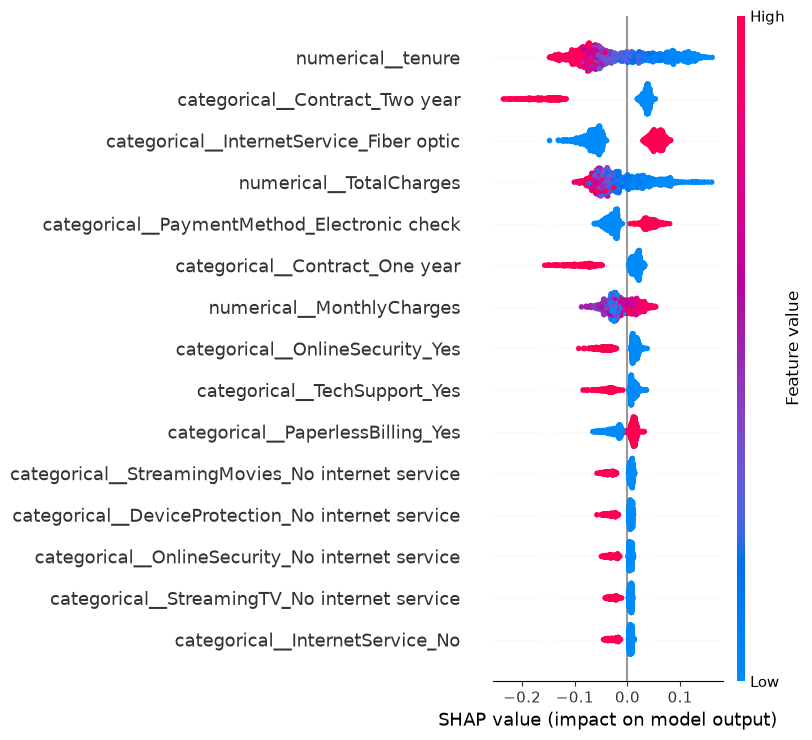

In [159]:
shap.summary_plot(
    shap_values_churn,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15
)

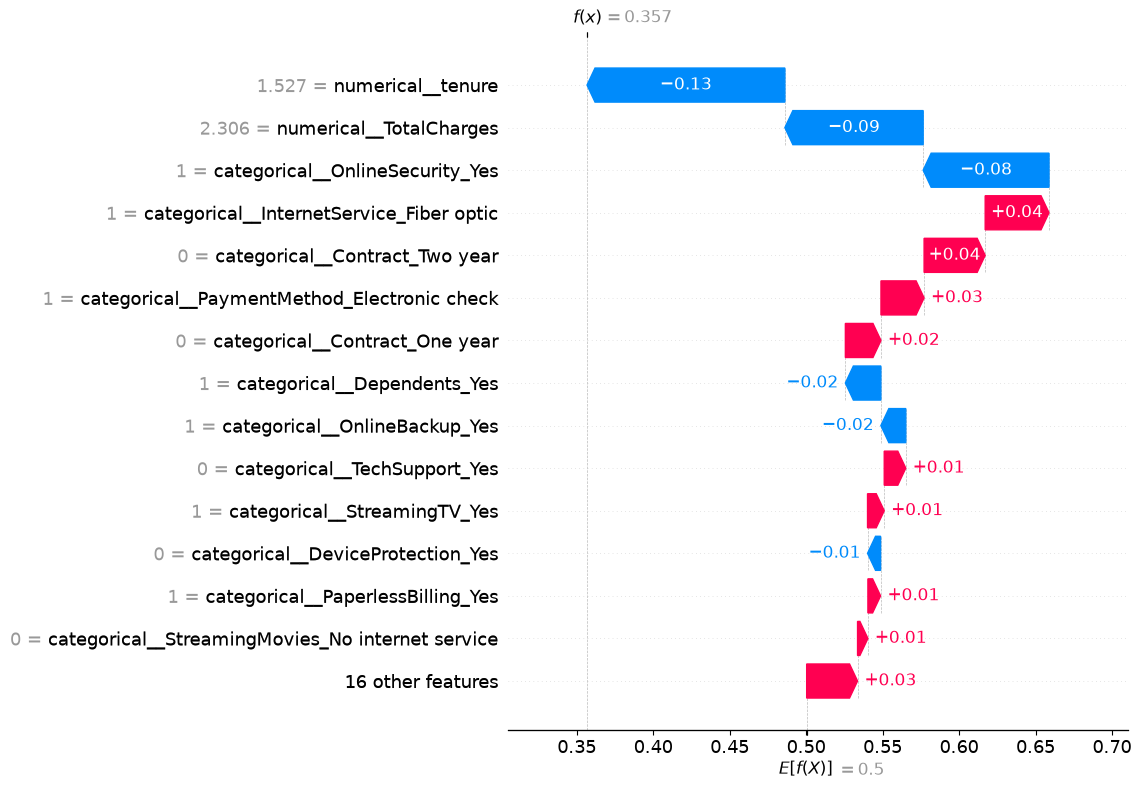

In [160]:
customer_index = 10

customer_transformed = X_test_transformed[
    customer_index:customer_index + 1
]

customer_shap = shap_values_churn[customer_index]

customer_data = (
    customer_transformed.toarray()[0]
    if hasattr(customer_transformed, "toarray")
    else customer_transformed[0]
)

customer_explanation = shap.Explanation(
    values=customer_shap,
    base_values=explainer.expected_value[1],
    data=customer_data,
    feature_names=feature_names
)

shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

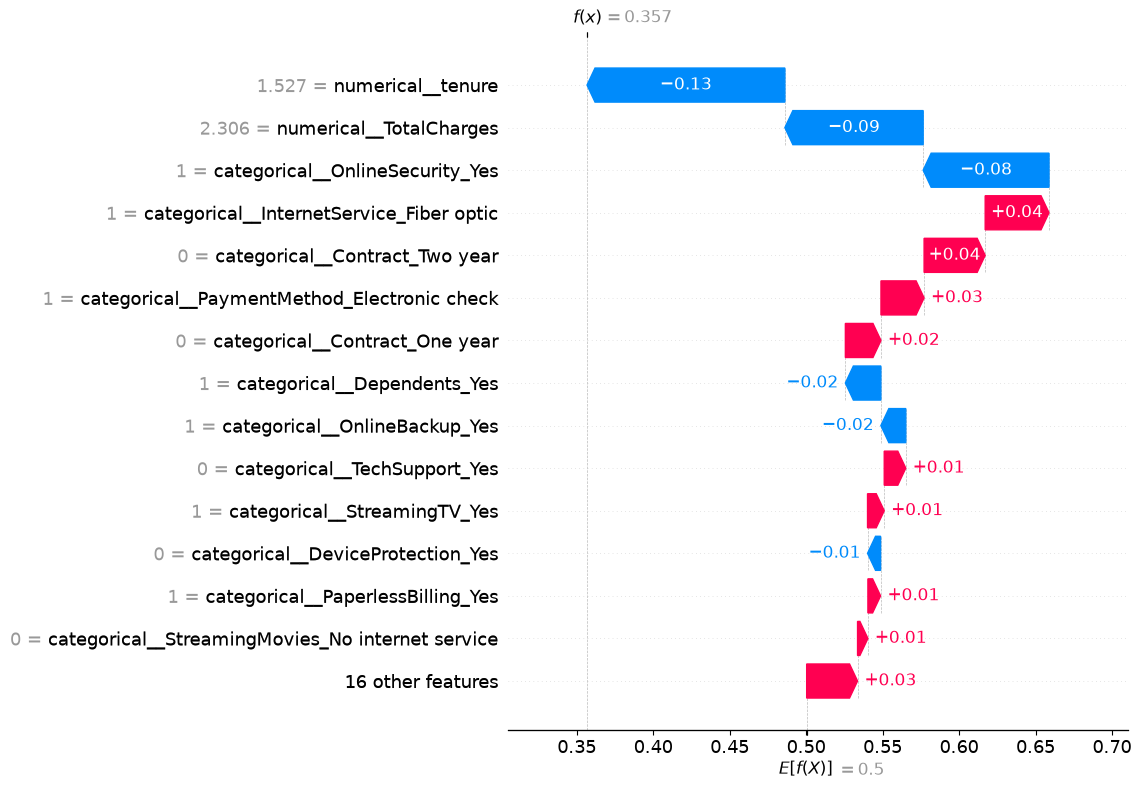

In [161]:
customer_index = 10

customer_transformed = X_test_transformed[
    customer_index:customer_index + 1
]

customer_shap = shap_values_churn[customer_index]

customer_data = (
    customer_transformed.toarray()[0]
    if hasattr(customer_transformed, "toarray")
    else customer_transformed[0]
)

customer_explanation = shap.Explanation(
    values=customer_shap,
    base_values=explainer.expected_value[1],
    data=customer_data,
    feature_names=feature_names
)

shap.plots.waterfall(
    customer_explanation,
    max_display=15
)

In [162]:
import joblib
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

final_model_path = models_dir / "churn_model.pkl"

joblib.dump(
    grid_rf.best_estimator_,
    final_model_path
)

print("Model saved successfully!")
print("Path:", final_model_path)

Model saved successfully!
Path: ..\models\churn_model.pkl


In [163]:
loaded_model = joblib.load(final_model_path)

test_customer = X_test.iloc[[0]]

prediction = loaded_model.predict(test_customer)
probability = loaded_model.predict_proba(test_customer)[0, 1]

print("Prediction:", prediction[0])
print("Churn probability:", probability)
print("Churn probability %:", probability * 100)

Prediction: 0
Churn probability: 0.02833570473777458
Churn probability %: 2.833570473777458
